# Trabalho AP2 — Projeto Profissional de Aprendizado de Máquina com AutoGluon

## 1. Formulação do Problema

Este projeto desenvolve um experimento completo de **aprendizado de máquina supervisionado** para prever se um cliente de uma instituição bancária portuguesa aceitará uma oferta de **depósito a prazo** após uma campanha de marketing direto por telefone.

**Pergunta de negócio:** com base nas características do cliente e nos dados disponíveis antes ou durante a campanha, é possível estimar se ele aceitará a oferta?

**Variável-alvo:** `contratou`, originalmente chamada `y` na base. Ela indica se o cliente assinou (`sim`) ou não assinou (`nao`) o depósito a prazo.

**Classes do problema:**
- `sim`: cliente aceitou a oferta. Esta é a classe positiva e a classe de maior interesse para a campanha.
- `nao`: cliente não aceitou a oferta. Esta é a classe majoritária.

**Por que é classificação supervisionada?** Cada linha da base possui variáveis explicativas e um rótulo real conhecido (`contratou`). O modelo aprende a relação entre esses dados históricos e a resposta do cliente para prever novos casos.

**Uso prático pelo banco:** o modelo poderia priorizar clientes com maior probabilidade de aceitar, reduzindo ligações pouco promissoras, aumentando a eficiência dos atendentes e apoiando decisões de segmentação da campanha.

### Custo dos erros

Um **falso positivo** ocorre quando o modelo prevê `sim`, mas o cliente não aceita. O custo é uma ligação ou abordagem sem conversão.

Um **falso negativo** ocorre quando o modelo prevê `nao`, mas o cliente aceitaria. O custo é perder uma oportunidade real de venda.

Neste contexto, o falso negativo tende a ser mais prejudicial, pois deixa de aproveitar um cliente que poderia gerar receita. Ao mesmo tempo, muitos falsos positivos desperdiçam recursos da operação. Por isso, a métrica principal escolhida é o **F1-score**, que equilibra Precision e Recall para a classe `sim`. O Recall também será observado com atenção, pois indica quantos clientes que aceitariam foram encontrados pelo modelo.


## 2. Instalação e Importação das Bibliotecas

O enunciado exige execução no Google Colab e instalação com `uv`. A célula abaixo instala as bibliotecas necessárias. Caso o ambiente já tenha os pacotes, a instalação apenas confirma as dependências.


In [ ]:
!pip -q install uv
!uv pip install --system -q "autogluon.tabular" scikit-learn pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.1/25.1 MB 29.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from autogluon.tabular import TabularPredictor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


## 3. Carregamento e Padronização dos Dados

A base é carregada diretamente pela URL fornecida no enunciado. Em seguida, a variável-alvo é padronizada para `contratou` e seus valores são mantidos em português (`sim`/`nao`).


In [ ]:
url = "https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/marketing_bancario.csv"

df = pd.read_csv(url, sep=";")
df.columns = df.columns.str.strip()

if "y" in df.columns and "contratou" not in df.columns:
    df = df.rename(columns={"y": "contratou"})

mapa_classes = {"yes": "sim", "no": "nao", "sim": "sim", "nao": "nao"}
df["contratou"] = df["contratou"].map(mapa_classes).fillna(df["contratou"])

TARGET = "contratou"
POSITIVE_LABEL = "sim"
NEGATIVE_LABEL = "nao"
COL_DURACAO = "duracao"
COL_IDADE = "idade"
COL_PROFISSAO = "profissao"
CLASSES = [NEGATIVE_LABEL, POSITIVE_LABEL]

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print("Colunas da base:")
print(df.columns.tolist())
display(df.head())


Linhas: 45,211
Colunas: 17
Colunas da base:
['idade', 'profissao', 'estado_civil', 'escolaridade', 'inadimplente', 'saldo', 'emprestimo_habitacional', 'emprestimo_pessoal', 'tipo_contato', 'dia', 'mes', 'duracao', 'contatos_campanha', 'dias_ultimo_contato', 'contatos_anteriores', 'resultado_anterior', 'contratou']


,idade,profissao,estado_civil,escolaridade,inadimplente,saldo,emprestimo_habitacional,emprestimo_pessoal,tipo_contato,dia,mes,duracao,contatos_campanha,dias_ultimo_contato,contatos_anteriores,resultado_anterior,contratou
0,58,gerencia,casado,superior,nao,2143,sim,nao,desconhecido,5,mai,261,1,-1,0,desconhecido,nao
1,44,tecnico,solteiro,medio,nao,29,sim,nao,desconhecido,5,mai,151,1,-1,0,desconhecido,nao
2,33,empresario,casado,medio,nao,2,sim,sim,desconhecido,5,mai,76,1,-1,0,desconhecido,nao
3,47,operario,casado,desconhecido,nao,1506,sim,nao,desconhecido,5,mai,92,1,-1,0,desconhecido,nao
4,33,desconhecido,solteiro,desconhecido,nao,1,nao,nao,desconhecido,5,mai,198,1,-1,0,desconhecido,nao


## 4. Análise Exploratória dos Dados

A análise exploratória verifica estrutura, tipos, valores ausentes, distribuição da classe-alvo, comportamento das variáveis numéricas e categóricas e possíveis problemas de vazamento de dados.


In [ ]:
tipos = pd.DataFrame({
    "variavel": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique().values,
    "exemplos": [df[col].dropna().unique()[:5].tolist() for col in df.columns],
})
display(tipos)


,variavel,tipo,valores_unicos,exemplos
0,idade,int64,77,"[58, 44, 33, 47, 35]"
1,profissao,object,12,"[gerencia, tecnico, empresario, operario, desc..."
2,estado_civil,object,3,"[casado, solteiro, divorciado]"
3,escolaridade,object,4,"[superior, medio, desconhecido, fundamental]"
4,inadimplente,object,2,"[nao, sim]"
5,saldo,int64,7168,"[2143, 29, 2, 1506, 1]"
6,emprestimo_habitacional,object,2,"[sim, nao]"
7,emprestimo_pessoal,object,2,"[nao, sim]"
8,tipo_contato,object,3,"[desconhecido, celular, telefone]"
9,dia,int64,31,"[5, 6, 7, 8, 9]"


In [ ]:
missing = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "% ausentes": (df.isna().mean() * 100).round(2),
}).sort_values("ausentes", ascending=False)

if missing["ausentes"].sum() == 0:
    print("Nenhum valor ausente encontrado na base.")
else:
    display(missing[missing["ausentes"] > 0])


Nenhum valor ausente encontrado na base.


,contagem,%
contratou,,
nao,39922,88.3
sim,5289,11.7


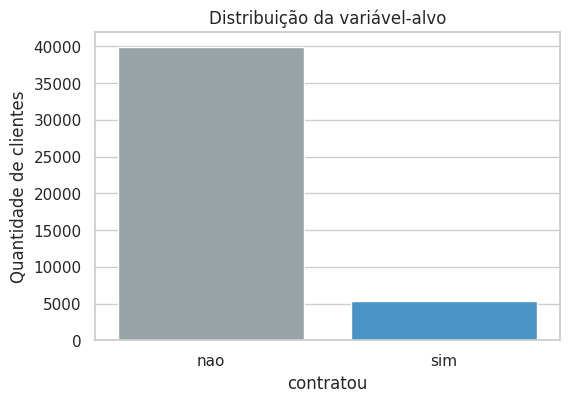

In [ ]:
dist = df[TARGET].value_counts().reindex(CLASSES)
dist_pct = (df[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100).round(2)
dist_alvo = pd.DataFrame({"contagem": dist, "%": dist_pct})
display(dist_alvo)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=dist_alvo.index, y=dist_alvo["contagem"], ax=ax, palette=["#95a5a6", "#3498db"])
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("contratou")
ax.set_ylabel("Quantidade de clientes")
plt.show()


**Interpretação:** a base é desbalanceada: a maioria dos clientes pertence à classe `nao`. Portanto, uma acurácia alta pode ser enganosa, porque um modelo que sempre prevê a classe majoritária já pareceria bom em acurácia, mesmo sem encontrar clientes interessados. Por isso, Precision, Recall, F1-score, ROC-AUC e matriz de confusão são indispensáveis.


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)

print("Variáveis numéricas:", numeric_cols)
print("Variáveis categóricas:", categorical_cols)

display(df[numeric_cols].describe().T)


Variáveis numéricas: ['idade', 'saldo', 'dia', 'duracao', 'contatos_campanha', 'dias_ultimo_contato', 'contatos_anteriores']
Variáveis categóricas: ['profissao', 'estado_civil', 'escolaridade', 'inadimplente', 'emprestimo_habitacional', 'emprestimo_pessoal', 'tipo_contato', 'mes', 'resultado_anterior']


,count,mean,std,min,25%,50%,75%,max
idade,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
saldo,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
dia,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duracao,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
contatos_campanha,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
dias_ultimo_contato,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
contatos_anteriores,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


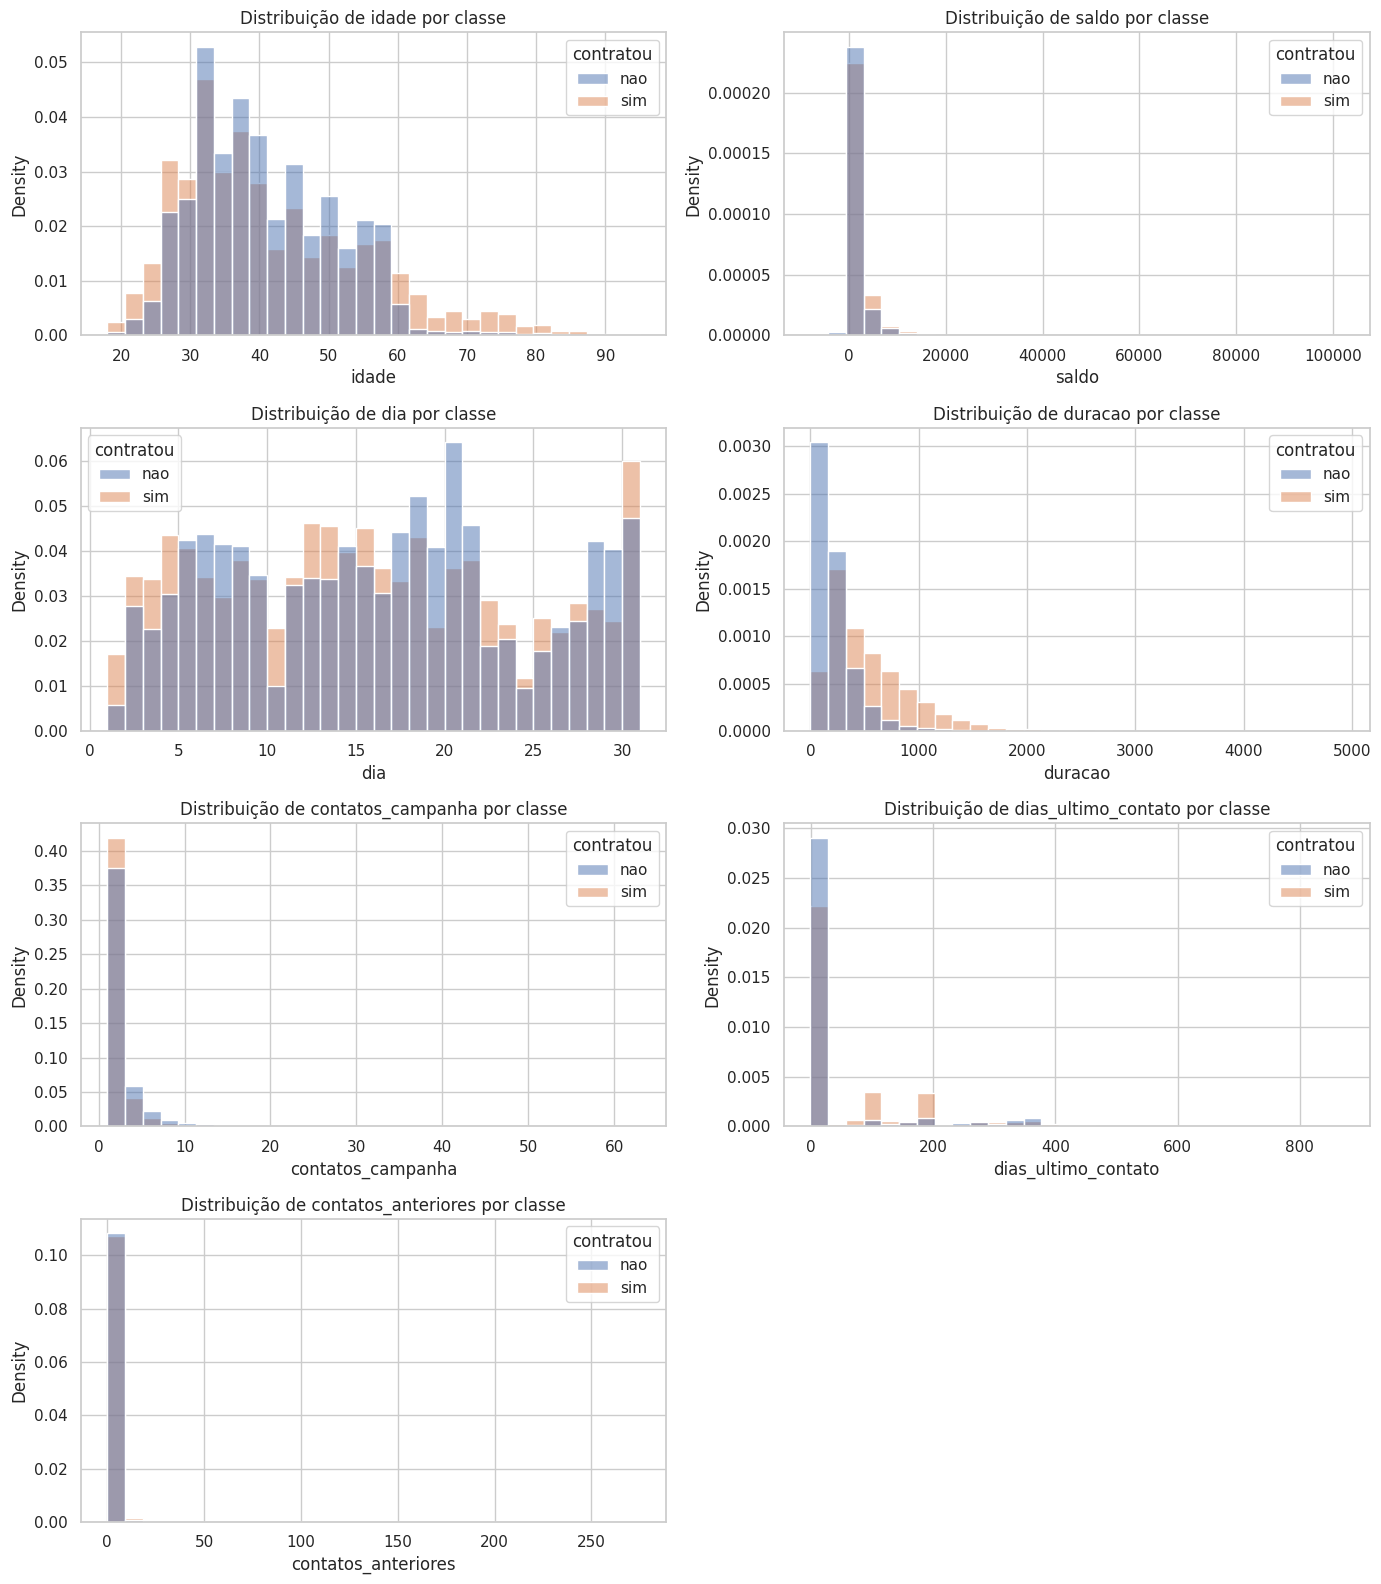

In [ ]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue=TARGET, bins=30, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribuição de {col} por classe")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Interpretação das variáveis numéricas:** variáveis como `idade`, `saldo`, `campanha`, `dias_desde_ultimo_contato`, `contatos_anteriores` e `duracao` ajudam a entender comportamento do cliente e histórico de contato. A variável `duracao` merece atenção especial porque tende a se relacionar fortemente com a aceitação, mas só é conhecida depois que a ligação acontece.



=== profissao ===


,taxa_aceitacao_%,n
profissao,,
estudante,28.68,938
aposentado,22.79,2264
desempregado,15.50,1303
gerencia,13.76,9458
administrativo,12.20,5171
autonomo,11.84,1579
desconhecido,11.81,288
tecnico,11.06,7597
servicos,8.88,4154


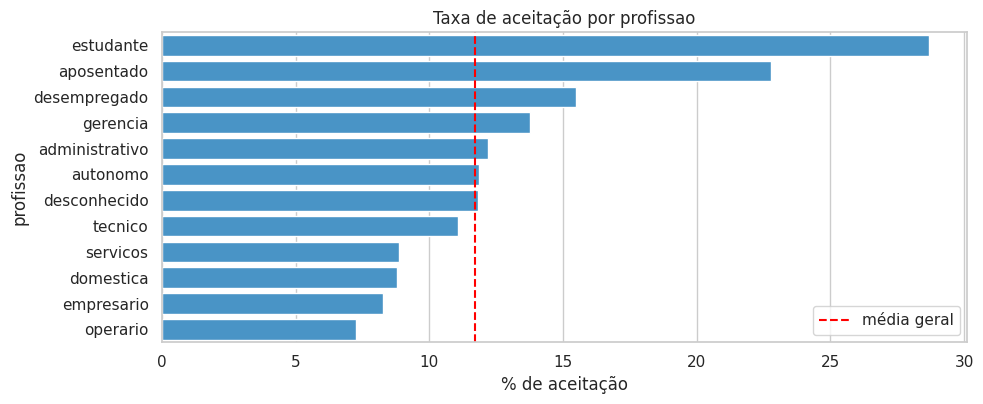


=== estado_civil ===


,taxa_aceitacao_%,n
estado_civil,,
solteiro,14.95,12790
divorciado,11.95,5207
casado,10.12,27214


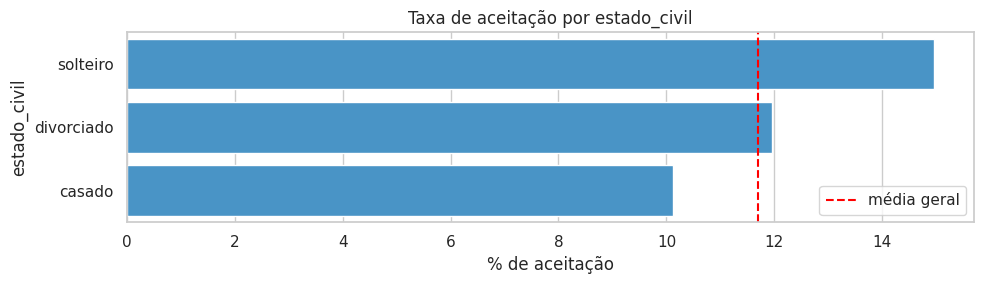


=== escolaridade ===


,taxa_aceitacao_%,n
escolaridade,,
superior,15.01,13301
desconhecido,13.57,1857
medio,10.56,23202
fundamental,8.63,6851


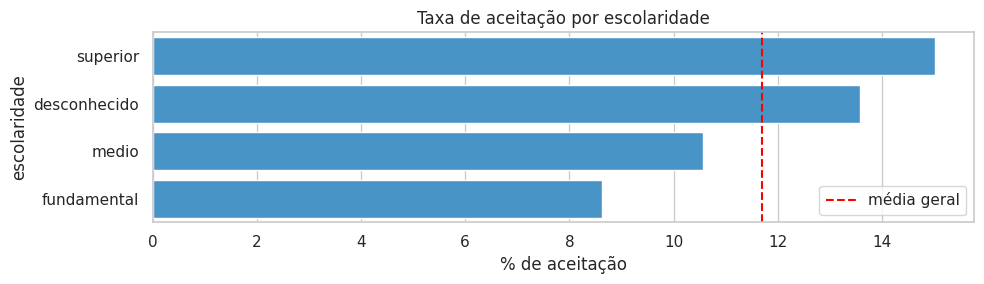


=== inadimplente ===


,taxa_aceitacao_%,n
inadimplente,,
nao,11.80,44396
sim,6.38,815


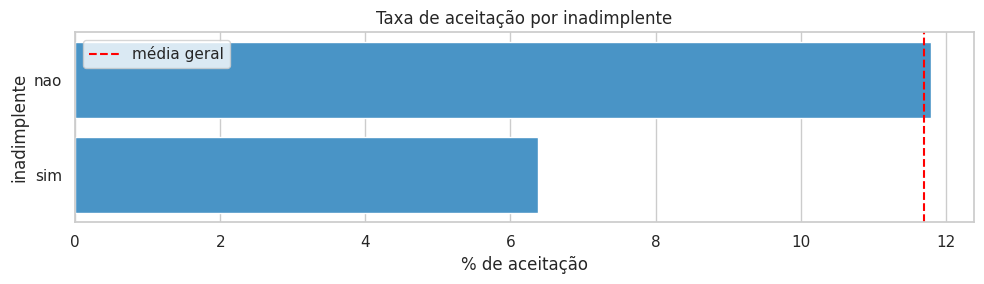


=== emprestimo_habitacional ===


,taxa_aceitacao_%,n
emprestimo_habitacional,,
nao,16.7,20081
sim,7.7,25130


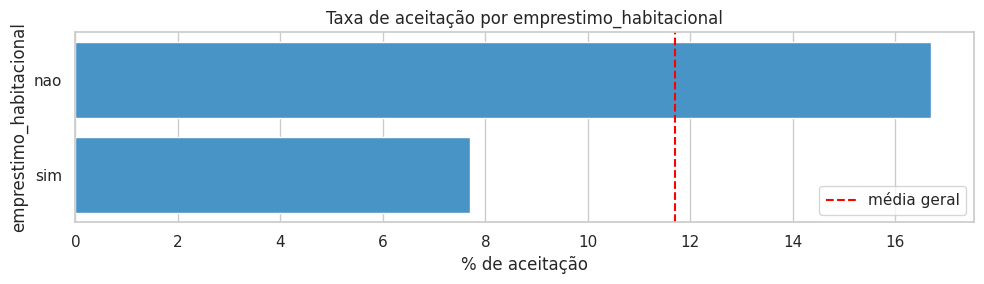


=== emprestimo_pessoal ===


,taxa_aceitacao_%,n
emprestimo_pessoal,,
nao,12.66,37967
sim,6.68,7244


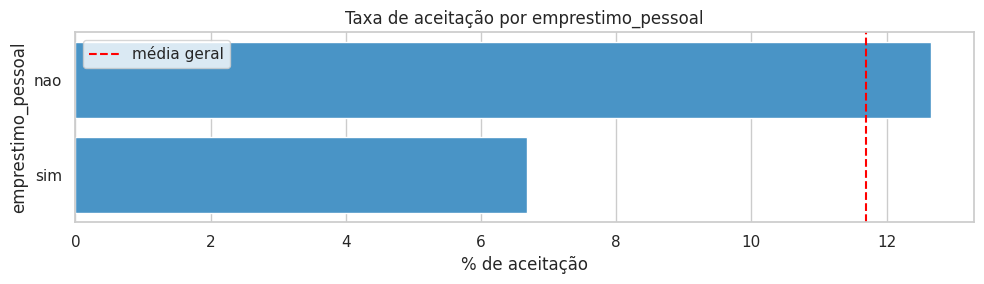


=== tipo_contato ===


,taxa_aceitacao_%,n
tipo_contato,,
celular,14.92,29285
telefone,13.42,2906
desconhecido,4.07,13020


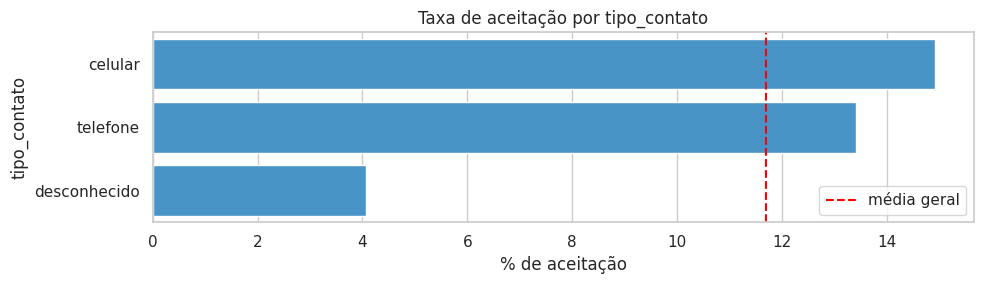


=== mes ===


,taxa_aceitacao_%,n
mes,,
mar,51.99,477
dez,46.73,214
set,46.46,579
out,43.77,738
abr,19.68,2932
fev,16.65,2649
ago,11.01,6247
jun,10.22,5341
nov,10.15,3970


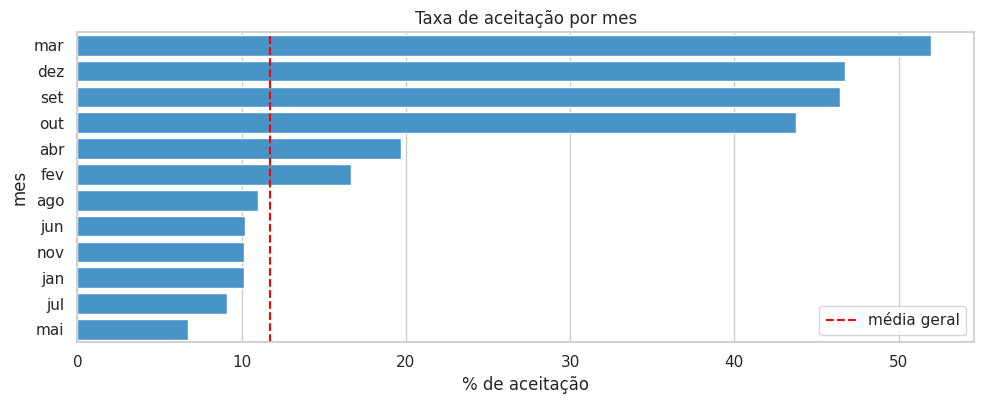


=== resultado_anterior ===


,taxa_aceitacao_%,n
resultado_anterior,,
sucesso,64.73,1511
outro,16.68,1840
fracasso,12.61,4901
desconhecido,9.16,36959


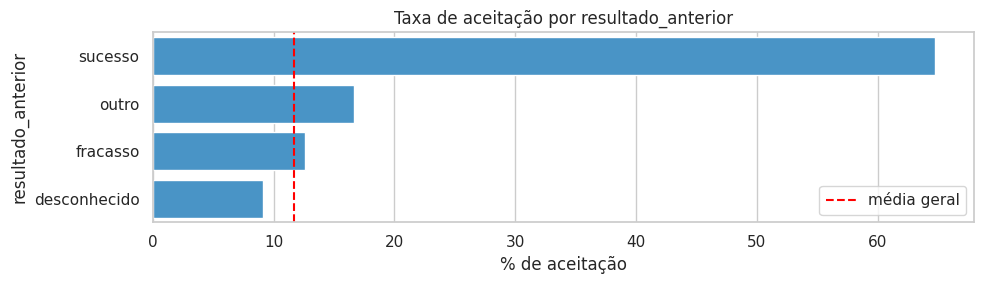

In [ ]:
for col in categorical_cols:
    taxa = (
        df.groupby(col)[TARGET]
        .apply(lambda s: (s == POSITIVE_LABEL).mean() * 100)
        .sort_values(ascending=False)
    )
    contagem = df[col].value_counts().reindex(taxa.index)
    resumo = pd.DataFrame({"taxa_aceitacao_%": taxa.round(2), "n": contagem})
    print(f"\n=== {col} ===")
    display(resumo)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(resumo))))
    sns.barplot(x=resumo["taxa_aceitacao_%"], y=resumo.index, ax=ax, color="#3498db")
    ax.axvline((df[TARGET] == POSITIVE_LABEL).mean() * 100, color="red", linestyle="--", label="média geral")
    ax.set_title(f"Taxa de aceitação por {col}")
    ax.set_xlabel("% de aceitação")
    ax.set_ylabel(col)
    ax.legend()
    plt.tight_layout()
    plt.show()


**Interpretação das variáveis categóricas:** algumas categorias apresentam taxas de aceitação acima da média, como certos perfis de profissão, resultado anterior de campanha e mês de contato. Essas diferenças indicam sinal preditivo real, mas também exigem cuidado: variáveis ligadas a grupos sociais podem gerar impactos diferentes entre segmentos e precisam ser avaliadas na análise de robustez.


## 5. Identificação de Data Leakage

A variável `duracao` representa a duração da ligação. Ela é problemática porque, em uma aplicação real de priorização, o banco quer decidir **antes** de ligar para o cliente. Nesse momento, a duração da chamada ainda não existe.

Usar `duracao` pode inflar artificialmente o desempenho do modelo: ligações mais longas tendem a estar associadas a maior chance de venda, mas essa informação só aparece depois da interação. Por isso, o trabalho treina dois modelos AutoGluon:

1. **AutoGluon com `duracao`**: serve para demonstrar o efeito do vazamento.
2. **AutoGluon sem `duracao`**: é a versão válida para uso real antes da ligação.


,count,mean,std,min,25%,50%,75%,max
contratou,,,,,,,,
nao,39922.0,221.18,207.38,0.0,95.0,164.0,279.0,4918.0
sim,5289.0,537.29,392.53,8.0,244.0,426.0,725.0,3881.0


,faixa_duracao,taxa_aceitacao_%
0,"(-0.001, 89.0]",0.724876
1,"(89.0, 147.0]",3.720057
2,"(147.0, 223.0]",7.931760
3,"(223.0, 368.0]",13.055092
4,"(368.0, 4918.0]",33.171002


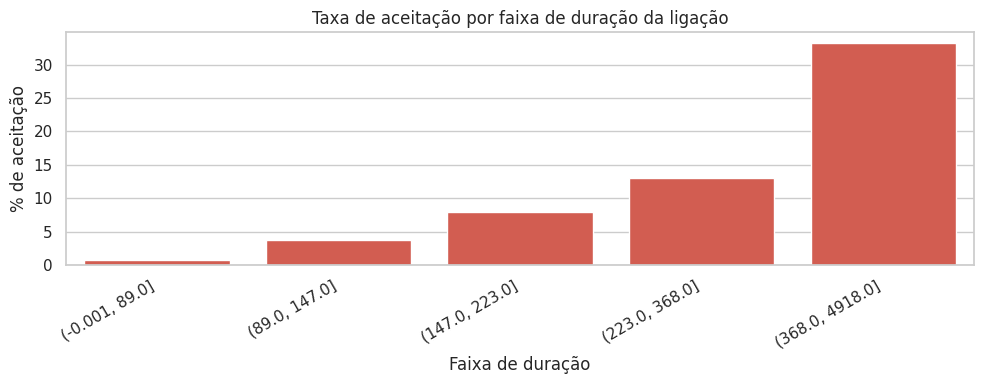

In [ ]:
if COL_DURACAO in df.columns:
    duracao_por_classe = df.groupby(TARGET)[COL_DURACAO].describe().round(2)
    display(duracao_por_classe)

    df_aux = df.copy()
    df_aux["faixa_duracao"] = pd.qcut(df_aux[COL_DURACAO], q=5, duplicates="drop")
    taxa_duracao = (
        df_aux.groupby("faixa_duracao")[TARGET]
        .apply(lambda s: (s == POSITIVE_LABEL).mean() * 100)
        .rename("taxa_aceitacao_%")
        .reset_index()
    )
    display(taxa_duracao)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=taxa_duracao, x="faixa_duracao", y="taxa_aceitacao_%", ax=ax, color="#e74c3c")
    ax.set_title("Taxa de aceitação por faixa de duração da ligação")
    ax.set_xlabel("Faixa de duração")
    ax.set_ylabel("% de aceitação")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("A coluna duracao não foi encontrada na base.")


**Interpretação:** se a taxa de aceitação cresce muito nas faixas de maior duração, isso confirma que a variável possui grande poder preditivo. Porém, esse poder vem de uma informação indisponível no momento da decisão. Logo, `duracao` deve ser removida do modelo recomendado para uso real.


## 6. Separação Correta entre Treino, Validação e Teste

A base será dividida em:

- **Treino/desenvolvimento (80%)**: usado para treinar os modelos.
- **Teste final (20%)**: usado somente para a avaliação final.

A divisão usa estratificação pela variável-alvo para preservar a proporção entre `sim` e `nao`. Dentro do treino, será separado também um conjunto de **validação** para ajustes internos, como eventual escolha de limiar. O teste permanece intocado até a avaliação final.


In [ ]:
train_full_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET],
)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_full_df[TARGET],
)

print(f"Treino:   {len(train_df):,} linhas ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validação:{len(val_df):,} linhas ({len(val_df)/len(df)*100:.1f}%)")
print(f"Teste:    {len(test_df):,} linhas ({len(test_df)/len(df)*100:.1f}%)")

for nome, base in [("Treino", train_df), ("Validação", val_df), ("Teste", test_df)]:
    print(f"\nProporção da variável-alvo — {nome}")
    display((base[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100).round(2).rename("%"))

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]


Treino:   28,934 linhas (64.0%)
Validação:7,234 linhas (16.0%)
Teste:    9,043 linhas (20.0%)

Proporção da variável-alvo — Treino


,%
contratou,
nao,88.3
sim,11.7



Proporção da variável-alvo — Validação


,%
contratou,
nao,88.31
sim,11.69



Proporção da variável-alvo — Teste


,%
contratou,
nao,88.3
sim,11.7


In [ ]:
def avaliar_modelo(nome_modelo, y_true, y_pred, y_proba=None, positive_label=POSITIVE_LABEL):
    """Calcula as métricas obrigatórias para classificação binária."""
    resultado = {
        "Modelo": nome_modelo,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "ROC-AUC": np.nan,
    }
    if y_proba is not None:
        y_bin = (pd.Series(y_true).reset_index(drop=True) == positive_label).astype(int)
        resultado["ROC-AUC"] = roc_auc_score(y_bin, y_proba)
    return resultado


def mostrar_avaliacao(nome, y_true, y_pred, y_proba=None, cmap="Blues"):
    resultado = avaliar_modelo(nome, y_true, y_pred, y_proba)
    display(pd.DataFrame([resultado]))

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(cmap=cmap)
    plt.title(f"Matriz de confusão — {nome}")
    plt.show()

    print(classification_report(y_true, y_pred, labels=CLASSES, zero_division=0))
    return resultado


## 7. Baselines Obrigatórios

Os baselines estabelecem uma referência mínima. Se o AutoGluon não superar esses modelos simples, isso deve ser discutido tecnicamente em vez de escondido.


### 7.1 Baseline 1 — Classe Majoritária

Este baseline sempre prevê `nao`, a classe mais frequente. Ele testa se a acurácia alta é apenas consequência do desbalanceamento.


,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,Classe majoritária,0.883003,0.0,0.0,0.0,NaN


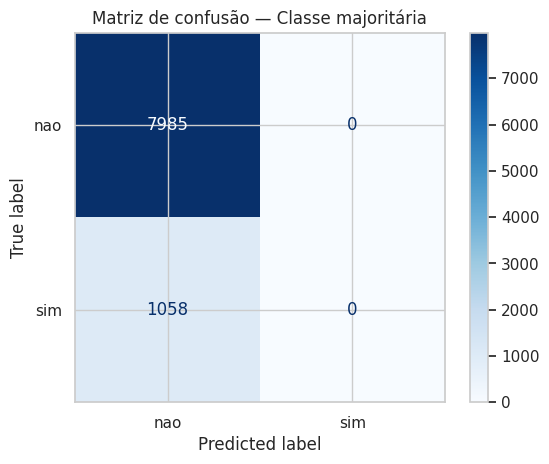

              precision    recall  f1-score   support

         nao       0.88      1.00      0.94      7985
         sim       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



In [ ]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

res_dummy = mostrar_avaliacao("Classe majoritária", y_test, pred_dummy, cmap="Blues")


**Interpretação:** este modelo tende a ter acurácia próxima ao percentual da classe `nao`, mas Recall e F1-score iguais a zero para `sim`. Ele não encontra nenhum cliente que aceitaria a oferta, portanto não é útil para a campanha.


### 7.2 Baseline 2 — Regressão Logística SEM `duracao`

A regressão logística é um modelo simples e interpretável. Para manter o baseline alinhado ao uso real, ela também será treinada **sem `duracao`**, evitando que o baseline seja beneficiado pelo mesmo vazamento discutido no trabalho. As variáveis numéricas são padronizadas e as categóricas passam por One-Hot Encoding. O parâmetro `class_weight="balanced"` ajuda a compensar o desbalanceamento da classe positiva.


,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,Regressão logística sem duracao,0.755059,0.267764,0.630435,0.375881,0.77202


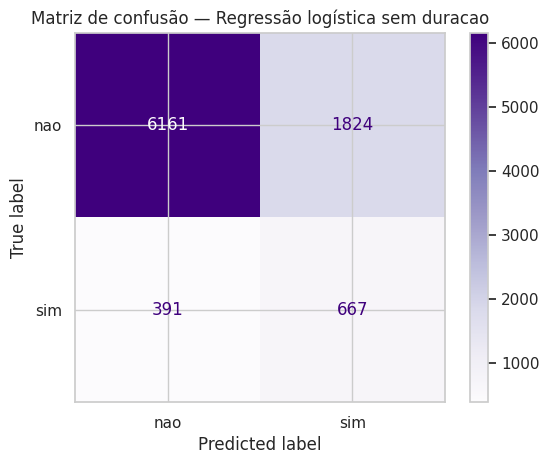

              precision    recall  f1-score   support

         nao       0.94      0.77      0.85      7985
         sim       0.27      0.63      0.38      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



In [ ]:
X_train_lr = X_train.drop(columns=[COL_DURACAO])
X_test_lr = X_test.drop(columns=[COL_DURACAO])

num_feats = X_train_lr.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_feats = X_train_lr.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])

log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

log_reg.fit(X_train_lr, y_train)
pred_lr = log_reg.predict(X_test_lr)
proba_lr = log_reg.predict_proba(X_test_lr)[:, list(log_reg.classes_).index(POSITIVE_LABEL)]

res_lr = mostrar_avaliacao("Regressão logística sem duracao", y_test, pred_lr, proba_lr, cmap="Purples")


**Interpretação:** a regressão logística deve superar o baseline ingênuo em Recall e F1-score, indicando que há sinal útil nas variáveis. Ela é uma referência forte porque é simples, rápida e usa ponderação de classes.


## 8. Modelagem com AutoGluon

A ferramenta principal do trabalho é o `TabularPredictor` do AutoGluon. A métrica de otimização escolhida é `f1`, coerente com a classe positiva desbalanceada e com o custo dos erros.

O tempo máximo de treinamento foi definido como 300 segundos para cada experimento, equilibrando qualidade e viabilidade no Colab.


### 8.1 AutoGluon COM `duracao`

Este experimento mostra o impacto da variável suspeita de vazamento. Ele não deve ser escolhido para uso real antes da ligação.


In [ ]:
path_com_duracao = "autogluon_com_duracao"
if os.path.exists(path_com_duracao):
    shutil.rmtree(path_com_duracao)

predictor_com_duracao = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="f1",
    positive_class=POSITIVE_LABEL,
    path=path_com_duracao,
).fit(
    train_data=train_df,
    tuning_data=val_df,
    time_limit=300,
    presets="medium_quality",
    verbosity=1,
)

leaderboard_com = predictor_com_duracao.leaderboard(test_df, silent=True)
print("--- Leaderboard AutoGluon COM duracao ---")
display(leaderboard_com)


		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.


--- Leaderboard AutoGluon COM duracao ---


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.631667,0.630715,f1,0.503372,0.347193,179.446373,0.003945,0.003914,0.708411,2,True,11
1,LightGBMXT,0.624133,0.577483,f1,0.508457,0.322266,10.633267,0.508457,0.322266,10.633267,1,True,1
2,NeuralNetFastAI,0.622779,0.623791,f1,0.171081,0.135789,48.948698,0.171081,0.135789,48.948698,1,True,7
3,LightGBM,0.617100,0.586319,f1,0.242827,0.141253,2.810938,0.242827,0.141253,2.810938,1,True,2
4,NeuralNetTorch,0.607520,0.598398,f1,0.085520,0.066237,126.978325,0.085520,0.066237,126.978325,1,True,9
5,LightGBMLarge,0.607211,0.574454,f1,0.439449,0.318055,5.087032,0.439449,0.318055,5.087032,1,True,10
6,XGBoost,0.601997,0.588389,f1,0.132056,0.106856,8.739113,0.132056,0.106856,8.739113,1,True,8
7,RandomForestEntr,0.588981,0.501466,f1,1.020967,0.271562,12.245930,1.020967,0.271562,12.245930,1,True,4
8,RandomForestGini,0.587786,0.499637,f1,1.255869,0.315150,11.955564,1.255869,0.315150,11.955564,1,True,3
9,ExtraTreesGini,0.539075,0.433121,f1,1.160147,0.629500,6.616894,1.160147,0.629500,6.616894,1,True,5


,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,AutoGluon com duracao,0.902245,0.564829,0.716446,0.631667,0.93227


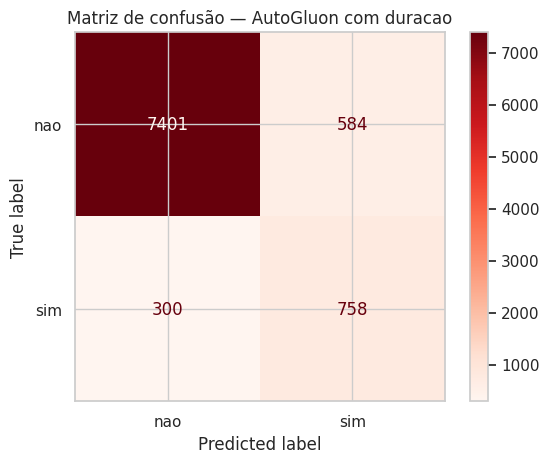

              precision    recall  f1-score   support

         nao       0.96      0.93      0.94      7985
         sim       0.56      0.72      0.63      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.82      0.79      9043
weighted avg       0.91      0.90      0.91      9043



In [ ]:
pred_ag_com = predictor_com_duracao.predict(X_test)
proba_ag_com = predictor_com_duracao.predict_proba(X_test)[POSITIVE_LABEL]

res_ag_com = mostrar_avaliacao("AutoGluon com duracao", y_test, pred_ag_com, proba_ag_com, cmap="Reds")


**Interpretação do leaderboard com `duracao`:** observe o primeiro modelo da tabela, sua métrica `score_test`, o tempo de treinamento (`fit_time`) e se há `WeightedEnsemble`. Caso o desempenho seja muito superior ao modelo sem `duracao`, isso reforça a hipótese de vazamento. Mesmo que tenha a melhor métrica, esse modelo não é viável para priorização antes da chamada.


### 8.2 AutoGluon SEM `duracao`

Este é o experimento válido para uso real, pois remove a variável que só seria conhecida após a ligação.


In [ ]:
train_sem = train_df.drop(columns=[COL_DURACAO])
val_sem = val_df.drop(columns=[COL_DURACAO])
test_sem = test_df.drop(columns=[COL_DURACAO])

X_val_sem = val_sem.drop(columns=[TARGET])
X_test_sem = test_sem.drop(columns=[TARGET])

print(f"Coluna removida: {COL_DURACAO}")
print(f"Colunas restantes no treino sem vazamento: {train_sem.shape[1]}")


Coluna removida: duracao
Colunas restantes no treino sem vazamento: 16


In [ ]:
path_sem_duracao = "autogluon_sem_duracao"
if os.path.exists(path_sem_duracao):
    shutil.rmtree(path_sem_duracao)

predictor_sem_duracao = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="f1",
    positive_class=POSITIVE_LABEL,
    path=path_sem_duracao,
).fit(
    train_data=train_sem,
    tuning_data=val_sem,
    time_limit=300,
    presets="medium_quality",
    verbosity=1,
)

leaderboard_sem = predictor_sem_duracao.leaderboard(test_sem, silent=True)
print("--- Leaderboard AutoGluon SEM duracao ---")
display(leaderboard_sem)


		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.


--- Leaderboard AutoGluon SEM duracao ---


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.500907,0.390405,f1,0.186031,0.195579,3.261723,0.186031,0.195579,3.261723,1,True,2
1,LightGBMXT,0.495905,0.392977,f1,0.230790,0.184602,2.946748,0.230790,0.184602,2.946748,1,True,1
2,LightGBMLarge,0.495247,0.376812,f1,0.219165,0.164344,3.522685,0.219165,0.164344,3.522685,1,True,10
3,XGBoost,0.482472,0.402878,f1,0.161681,0.113318,10.006048,0.161681,0.113318,10.006048,1,True,8
4,WeightedEnsemble_L2,0.481547,0.427469,f1,0.528301,0.413814,123.547899,0.003566,0.003499,0.698787,2,True,11
5,NeuralNetFastAI,0.476596,0.404372,f1,0.160253,0.128838,45.650149,0.160253,0.128838,45.650149,1,True,7
6,NeuralNetTorch,0.467811,0.422535,f1,0.074780,0.061369,116.379678,0.074780,0.061369,116.379678,1,True,9
7,RandomForestGini,0.463025,0.313830,f1,0.799039,0.382576,9.933677,0.799039,0.382576,9.933677,1,True,3
8,RandomForestEntr,0.458708,0.329787,f1,1.088073,0.367627,11.287313,1.088073,0.367627,11.287313,1,True,4
9,ExtraTreesGini,0.452926,0.318345,f1,1.579833,0.452391,7.058318,1.579833,0.452391,7.058318,1,True,5


,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,AutoGluon sem duracao,0.869512,0.449918,0.517958,0.481547,0.796871


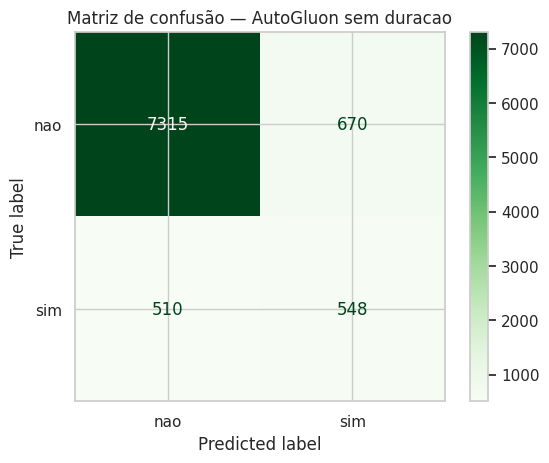

              precision    recall  f1-score   support

         nao       0.93      0.92      0.93      7985
         sim       0.45      0.52      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043



In [ ]:
pred_ag_sem = predictor_sem_duracao.predict(X_test_sem)
proba_ag_sem = predictor_sem_duracao.predict_proba(X_test_sem)[POSITIVE_LABEL]

res_ag_sem = mostrar_avaliacao("AutoGluon sem duracao", y_test, pred_ag_sem, proba_ag_sem, cmap="Greens")


**Interpretação do leaderboard sem `duracao`:** a queda de desempenho em relação ao modelo com `duracao` é esperada e tecnicamente saudável, pois remove uma informação indisponível no momento da decisão. O modelo sem `duracao` deve ser comparado com os baselines para verificar se ainda agrega valor real.


### 8.3 Ajuste de Limiar Sem Usar o Teste

Modelos binários normalmente usam limiar 0,5 para transformar probabilidade em classe. Como a base é desbalanceada, esse limiar pode não maximizar F1. Para respeitar a regra do enunciado, o limiar é escolhido **somente no conjunto de validação** e aplicado uma única vez ao teste final.


Melhor limiar no conjunto de validação: 0.23
F1 na validação com esse limiar: 0.4927


,Modelo,Acurácia,Precision,Recall,F1-score,ROC-AUC
0,AutoGluon sem duracao (limiar=0.23),0.868959,0.448163,0.518904,0.480946,0.796871


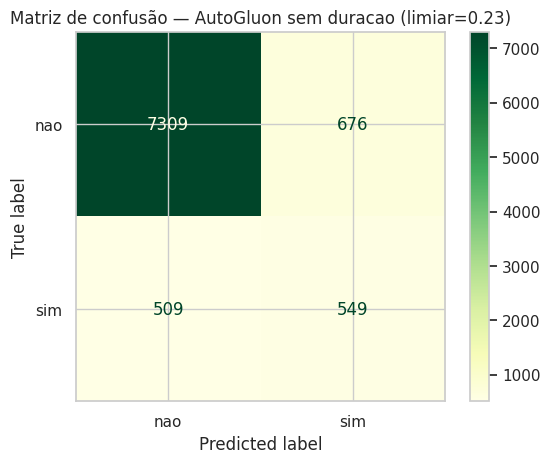

              precision    recall  f1-score   support

         nao       0.93      0.92      0.93      7985
         sim       0.45      0.52      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043



In [ ]:
def melhor_limiar_f1(y_true, proba, positive_label=POSITIVE_LABEL):
    """Escolhe o limiar que maximiza F1 usando apenas dados de validação."""
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []
    for t in thresholds:
        pred = np.where(proba >= t, positive_label, NEGATIVE_LABEL)
        scores.append(f1_score(y_true, pred, pos_label=positive_label, zero_division=0))
    melhor_idx = int(np.argmax(scores))
    return thresholds[melhor_idx], scores[melhor_idx]

proba_val_sem = predictor_sem_duracao.predict_proba(X_val_sem)[POSITIVE_LABEL]
limiar_sem, f1_val_sem = melhor_limiar_f1(y_val, proba_val_sem)
print(f"Melhor limiar no conjunto de validação: {limiar_sem:.2f}")
print(f"F1 na validação com esse limiar: {f1_val_sem:.4f}")

pred_ag_sem_limiar = np.where(proba_ag_sem >= limiar_sem, POSITIVE_LABEL, NEGATIVE_LABEL)
res_ag_sem_limiar = mostrar_avaliacao(
    f"AutoGluon sem duracao (limiar={limiar_sem:.2f})",
    y_test,
    pred_ag_sem_limiar,
    proba_ag_sem,
    cmap="YlGn",
)


**Interpretação:** este ajuste é válido porque o teste não foi usado para escolher o limiar. Se o F1 melhorar, significa que parte do ganho vem de alinhar a decisão ao objetivo de negócio, não de vazar informação do teste.


## 9. Comparação Final dos Modelos

A tabela abaixo compara os modelos exigidos no enunciado e inclui também a versão sem `duracao` com limiar ajustado na validação, pois ela representa uma alternativa operacional mais alinhada ao F1-score.


In [ ]:
resultados = pd.DataFrame([
    res_dummy,
    res_lr,
    res_ag_com,
    res_ag_sem,
    res_ag_sem_limiar,
])

metricas = ["Acurácia", "Precision", "Recall", "F1-score", "ROC-AUC"]
for col in metricas:
    resultados[col] = resultados[col].astype(float).round(4)

print("Tabela comparativa — conjunto de TESTE")
display(resultados.set_index("Modelo"))


Tabela comparativa — conjunto de TESTE


,Acurácia,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Classe majoritária,0.8830,0.0000,0.0000,0.0000,NaN
Regressão logística sem duracao,0.7551,0.2678,0.6304,0.3759,0.7720
AutoGluon com duracao,0.9022,0.5648,0.7164,0.6317,0.9323
AutoGluon sem duracao,0.8695,0.4499,0.5180,0.4815,0.7969
AutoGluon sem duracao (limiar=0.23),0.8690,0.4482,0.5189,0.4809,0.7969


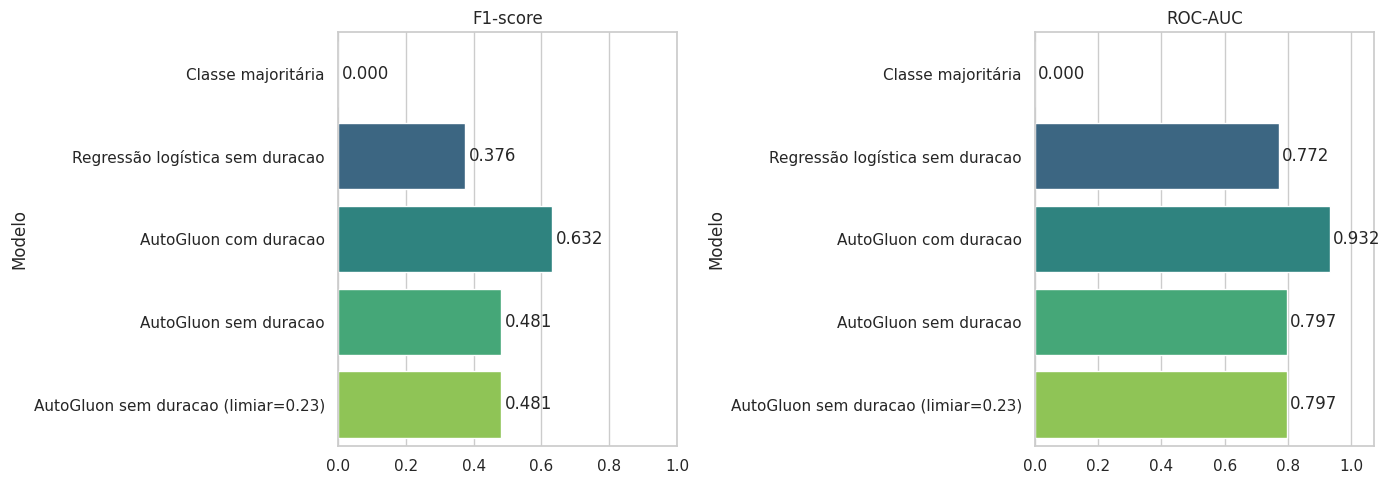

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = resultados.set_index("Modelo")

for ax, metrica in zip(axes, ["F1-score", "ROC-AUC"]):
    valores = plot_df[metrica].fillna(0)
    sns.barplot(x=valores.values, y=valores.index, ax=ax, palette="viridis")
    ax.set_title(metrica)
    ax.set_xlim(0, max(1, valores.max() * 1.15))
    for i, v in enumerate(valores.values):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()


**Qual modelo escolher?**

O modelo **AutoGluon com `duracao`** pode ter a melhor métrica, mas não deve ser usado para priorizar clientes antes da ligação, pois contém data leakage.

Para uso real, a escolha deve ficar entre os modelos **sem `duracao`**. A comparação correta é entre a regressão logística sem `duracao`, o AutoGluon sem `duracao` e a versão sem `duracao` com limiar ajustado na validação. Se o modelo simples superar o AutoGluon, isso não invalida o projeto: mostra que o baseline é competitivo e que o experimento foi avaliado com honestidade. A recomendação final deve considerar F1-score, Recall, ROC-AUC, interpretabilidade, simplicidade operacional e ausência de vazamento.

Em produção, eu recomendaria o melhor modelo **sem `duracao`** de acordo com a tabela de teste, dando preferência a uma solução simples se ela tiver desempenho igual ou superior ao AutoGluon e for mais fácil de explicar ao negócio.


## 10. Importância das Variáveis

A importância de variáveis do AutoGluon é calculada por permutação no conjunto de teste. A análise abaixo prioriza o modelo sem `duracao`, porque ele é o candidato válido para uso real. Em seguida, a importância do modelo com `duracao` é exibida apenas para evidenciar o risco de vazamento.


--- Importância das variáveis — AutoGluon SEM duracao ---


,importance,stddev,p_value,n,p99_high,p99_low
dias_ultimo_contato,0.113143,0.021090,0.000138,5,0.156568,0.069718
contatos_anteriores,0.112191,0.015741,0.000045,5,0.144601,0.079781
mes,0.096371,0.017369,0.000121,5,0.132134,0.060608
tipo_contato,0.059827,0.012267,0.000201,5,0.085085,0.034569
resultado_anterior,0.041557,0.006703,0.000078,5,0.055359,0.027755
dia,0.023959,0.007530,0.001031,5,0.039462,0.008455
contatos_campanha,0.016357,0.015755,0.040503,5,0.048797,-0.016083
emprestimo_pessoal,0.013873,0.004063,0.000790,5,0.022238,0.005508
emprestimo_habitacional,0.010806,0.008746,0.025353,5,0.028814,-0.007202
idade,0.003652,0.007826,0.177821,5,0.019766,-0.012462


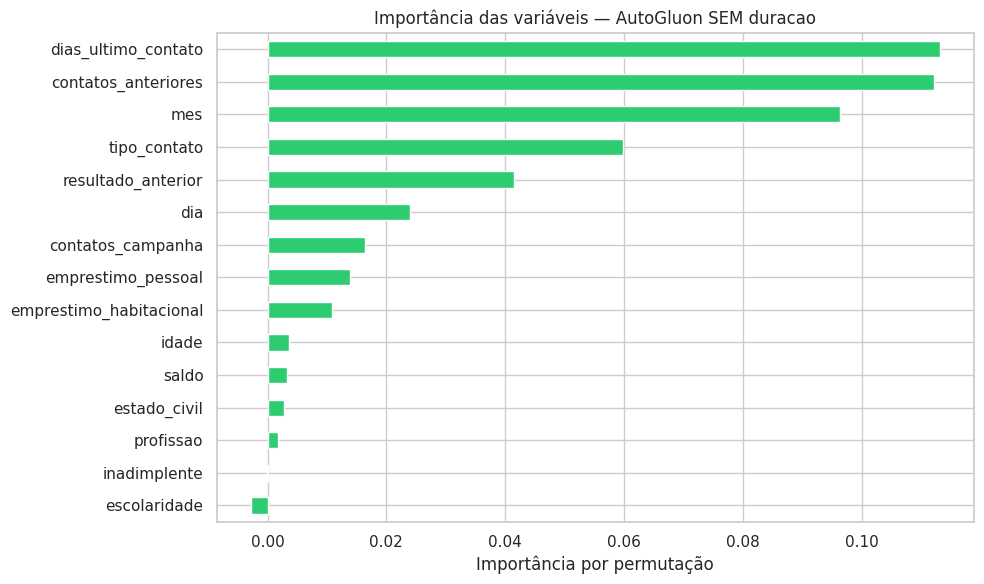

In [ ]:
print("--- Importância das variáveis — AutoGluon SEM duracao ---")
imp_sem = predictor_sem_duracao.feature_importance(test_sem)
display(imp_sem.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
imp_sem["importance"].head(15).sort_values().plot(kind="barh", ax=ax, color="#2ecc71")
ax.set_title("Importância das variáveis — AutoGluon SEM duracao")
ax.set_xlabel("Importância por permutação")
plt.tight_layout()
plt.show()


--- Importância das variáveis — AutoGluon COM duracao ---


,importance,stddev,p_value,n,p99_high,p99_low
duracao,0.309496,0.020986,0.000003,5,0.352707,0.266285
mes,0.152053,0.009042,0.000001,5,0.170671,0.133435
tipo_contato,0.086641,0.009625,0.000018,5,0.106460,0.066823
dia,0.064693,0.007267,0.000019,5,0.079656,0.049730
resultado_anterior,0.037281,0.004272,0.000020,5,0.046077,0.028484
dias_ultimo_contato,0.028818,0.005112,0.000114,5,0.039343,0.018293
emprestimo_habitacional,0.017531,0.005441,0.000983,5,0.028734,0.006329
contatos_campanha,0.017433,0.009454,0.007287,5,0.036900,-0.002033
profissao,0.009797,0.006728,0.015597,5,0.023649,-0.004056
saldo,0.008697,0.005454,0.011734,5,0.019926,-0.002533


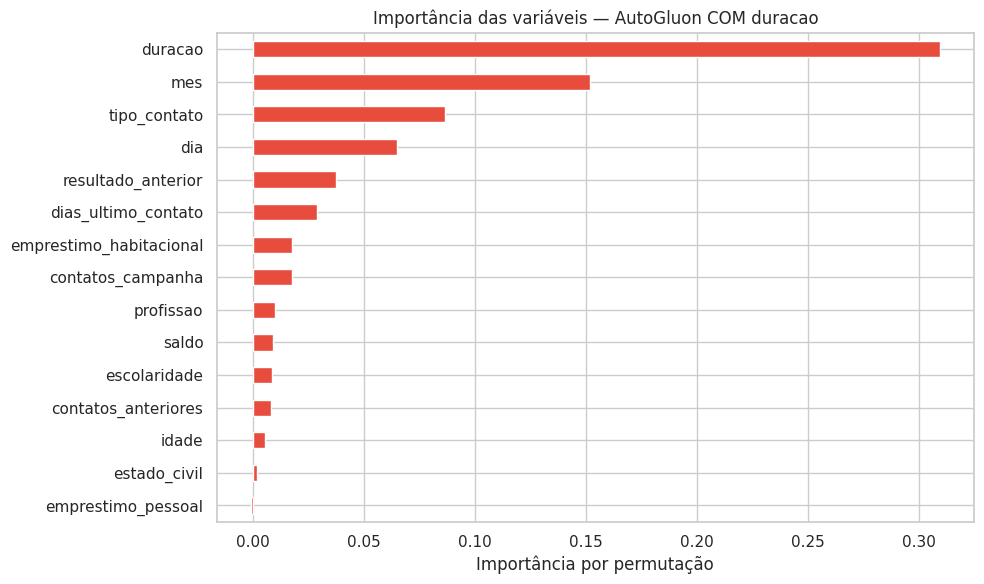

In [ ]:
print("--- Importância das variáveis — AutoGluon COM duracao ---")
imp_com = predictor_com_duracao.feature_importance(test_df)
display(imp_com.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
imp_com["importance"].head(15).sort_values().plot(kind="barh", ax=ax, color="#e74c3c")
ax.set_title("Importância das variáveis — AutoGluon COM duracao")
ax.set_xlabel("Importância por permutação")
plt.tight_layout()
plt.show()


**Interpretação de negócio:** variáveis como resultado de campanha anterior, mês de contato, histórico de contatos, idade, profissão e situação financeira podem influenciar a aceitação porque representam perfil do cliente, momento da abordagem e relacionamento prévio com o banco. Se `duracao` aparecer entre as variáveis mais importantes no modelo com vazamento, isso confirma que o desempenho elevado depende de uma informação que não estaria disponível no momento correto.

Também é importante observar variáveis associadas a grupos sociais, como profissão, escolaridade e estado civil. Elas podem melhorar a previsão, mas exigem análise de robustez para evitar que o modelo funcione muito pior para determinados segmentos.


## 11. Análise de Robustez por Grupos

A robustez verifica se o desempenho do modelo é parecido em diferentes segmentos. O enunciado exige pelo menos duas segmentações; serão analisadas **faixa etária** e **profissão** usando o modelo sem `duracao` com o limiar escolhido sem consultar o teste.


In [ ]:
def desempenho_por_grupo(base_teste, y_true, y_pred, coluna_grupo, positive_label=POSITIVE_LABEL, min_amostras=50):
    temp = pd.DataFrame({
        "grupo": base_teste[coluna_grupo].values,
        "y_true": pd.Series(y_true).values,
        "y_pred": np.array(y_pred),
    })

    linhas = []
    for grupo, dados in temp.groupby("grupo"):
        if len(dados) < min_amostras:
            continue
        linhas.append({
            "grupo": grupo,
            "n": len(dados),
            "acuracia": accuracy_score(dados["y_true"], dados["y_pred"]),
            "precision": precision_score(dados["y_true"], dados["y_pred"], pos_label=positive_label, zero_division=0),
            "recall": recall_score(dados["y_true"], dados["y_pred"], pos_label=positive_label, zero_division=0),
            "f1": f1_score(dados["y_true"], dados["y_pred"], pos_label=positive_label, zero_division=0),
        })

    return pd.DataFrame(linhas).sort_values("f1", ascending=False).round(4)


=== Robustez por faixa etária ===


,grupo,n,acuracia,precision,recall,f1
3,acima de 60,219,0.5205,0.4678,0.8511,0.6038
0,até 30,1327,0.8063,0.4228,0.5972,0.4951
2,46 a 60,2749,0.8909,0.4731,0.4632,0.4681
1,31 a 45,4748,0.8898,0.4423,0.4509,0.4466


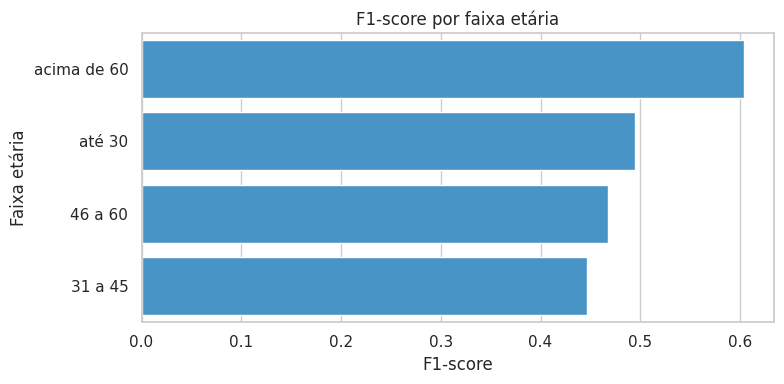

In [ ]:
test_robustez = test_sem.copy()
test_robustez["faixa_etaria"] = pd.cut(
    test_df[COL_IDADE],
    bins=[0, 30, 45, 60, 120],
    labels=["até 30", "31 a 45", "46 a 60", "acima de 60"],
    include_lowest=True,
)

rob_idade = desempenho_por_grupo(test_robustez, y_test, pred_ag_sem_limiar, "faixa_etaria")
print("=== Robustez por faixa etária ===")
display(rob_idade)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rob_idade, x="f1", y="grupo", ax=ax, color="#3498db")
ax.set_title("F1-score por faixa etária")
ax.set_xlabel("F1-score")
ax.set_ylabel("Faixa etária")
plt.tight_layout()
plt.show()


**Interpretação — faixa etária:** se jovens ou idosos apresentarem F1/Recall maior, o modelo pode estar capturando padrões reais de maior aceitação nesses grupos. Se alguma faixa tiver desempenho muito menor, isso pode gerar problema prático, pois a campanha ficaria menos eficiente para aquele segmento. Uma melhoria possível seria coletar mais dados, ajustar limiares por política de negócio ou monitorar métricas por grupo antes de colocar o modelo em produção.


=== Robustez por profissão ===


,grupo,n,acuracia,precision,recall,f1
1,aposentado,452,0.7279,0.4294,0.7000,0.5323
4,desempregado,279,0.8459,0.5106,0.5455,0.5275
7,estudante,180,0.6000,0.3854,0.7400,0.5068
8,gerencia,1947,0.8557,0.4656,0.5462,0.5027
11,tecnico,1529,0.8718,0.4558,0.5537,0.5000
2,autonomo,336,0.8661,0.5000,0.4889,0.4944
0,administrativo,1030,0.8553,0.4140,0.5328,0.4659
5,domestica,227,0.8811,0.4348,0.4167,0.4255
9,operario,1902,0.9295,0.5169,0.3358,0.4071
10,servicos,806,0.9045,0.4464,0.3521,0.3937


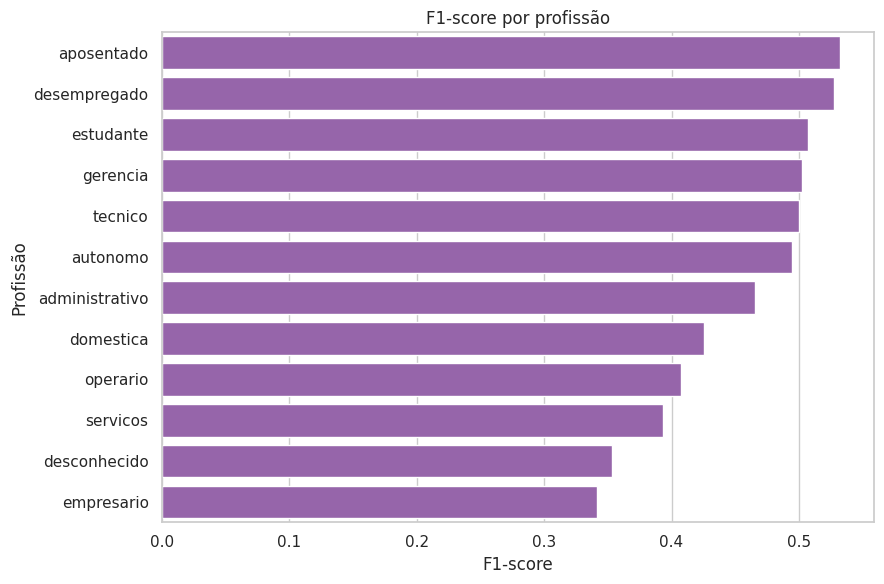

In [ ]:
if COL_PROFISSAO in test_sem.columns:
    rob_profissao = desempenho_por_grupo(test_sem, y_test, pred_ag_sem_limiar, COL_PROFISSAO)
    print("=== Robustez por profissão ===")
    display(rob_profissao)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=rob_profissao, x="f1", y="grupo", ax=ax, color="#9b59b6")
    ax.set_title("F1-score por profissão")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Profissão")
    plt.tight_layout()
    plt.show()
else:
    print("Coluna de profissão não encontrada.")


**Interpretação — profissão:** diferenças de desempenho por profissão podem indicar que o modelo identifica melhor grupos com maior taxa histórica de aceitação. Porém, se algum grupo tiver F1 muito baixo, a aplicação prática pode favorecer certos perfis e negligenciar outros. Antes de produção, seria necessário revisar essas diferenças, validar se são justificáveis do ponto de vista de negócio e monitorar possíveis vieses.


## 12. Relatório Técnico Final

### Significado das métricas no contexto

- **Acurácia:** percentual total de acertos, mas pode ser enganosa porque a classe `nao` é majoritária.
- **Precision:** entre clientes previstos como interessados, quantos realmente aceitaram.
- **Recall:** entre clientes que realmente aceitariam, quantos o modelo conseguiu encontrar.
- **F1-score:** equilíbrio entre Precision e Recall; é a métrica principal por lidar melhor com a classe positiva desbalanceada.
- **ROC-AUC:** capacidade geral de separar clientes que aceitam dos que não aceitam.
- **Matriz de confusão:** mostra acertos e erros por classe, permitindo enxergar falsos positivos e falsos negativos.

### Conclusão

**1. O AutoGluon superou os baselines?**

O AutoGluon com `duracao` tende a apresentar desempenho superior, mas esse resultado é contaminado por data leakage. A conclusão relevante é a comparação entre modelos sem `duracao`: regressão logística sem vazamento, AutoGluon sem vazamento e AutoGluon sem vazamento com limiar ajustado na validação. Se o AutoGluon superar o baseline, ele é a melhor opção preditiva; se não superar, o baseline simples passa a ser uma alternativa forte. Em ambos os casos, o experimento está correto porque a avaliação foi feita sem usar o teste para decisões de modelagem.

**2. O melhor modelo em métrica é também o melhor modelo para uso real?**

Não necessariamente. O modelo com `duracao` pode ter a melhor métrica, mas não é adequado para uso real antes da ligação. O melhor modelo operacional deve excluir `duracao` e manter desempenho consistente no teste e nos grupos analisados.

**3. A variável suspeita de data leakage deve ser usada ou removida?**

Deve ser removida do modelo recomendado para uso real. A variável `duracao` só é conhecida depois da chamada, então usá-la para decidir quem ligar seria uma avaliação artificial.

**4. O modelo seria útil para uma campanha bancária real?**

Sim, desde que usado como ferramenta de priorização e não como decisão automática definitiva. Um modelo sem vazamento pode ajudar o banco a ordenar clientes por probabilidade de aceitação, reduzir desperdício de ligações e melhorar a taxa de conversão.

**5. Próximos passos antes de produção:**

- Validar o modelo em campanhas mais recentes, preferencialmente com separação temporal.
- Definir o limiar de decisão com base em custos reais de falso positivo e falso negativo.
- Monitorar desempenho por grupo para reduzir riscos de viés.
- Verificar disponibilidade das variáveis no momento da decisão.
- Acompanhar drift dos dados e re-treinar o modelo periodicamente.


In [ ]:
print("=" * 80)
print("TABELA COMPARATIVA FINAL — CONJUNTO DE TESTE")
print("=" * 80)
display(resultados.set_index("Modelo"))

print("\nMétrica principal: F1-score")
print("Justificativa: equilibra Precision e Recall em uma base desbalanceada.")
print("\nRegra de uso real: modelos com duracao servem apenas para demonstrar vazamento;")
print("o modelo recomendado deve ser escolhido entre as versões sem duracao.")


TABELA COMPARATIVA FINAL — CONJUNTO DE TESTE


,Acurácia,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Classe majoritária,0.8830,0.0000,0.0000,0.0000,NaN
Regressão logística sem duracao,0.7551,0.2678,0.6304,0.3759,0.7720
AutoGluon com duracao,0.9022,0.5648,0.7164,0.6317,0.9323
AutoGluon sem duracao,0.8695,0.4499,0.5180,0.4815,0.7969
AutoGluon sem duracao (limiar=0.23),0.8690,0.4482,0.5189,0.4809,0.7969



Métrica principal: F1-score
Justificativa: equilibra Precision e Recall em uma base desbalanceada.

Regra de uso real: modelos com duracao servem apenas para demonstrar vazamento;
o modelo recomendado deve ser escolhido entre as versões sem duracao.
